<div style="background: linear-gradient(135deg, #5e2a8e 0%, #8e44ad 25%, #a569bd 50%, #bb8fce 75%, #d2b4de 100%); 
            padding: 50px; border-radius: 15px; text-align: center; box-shadow: 0 10px 30px rgba(0,0,0,0.5);">
    <h1 style="color: #ffffff; font-size: 48px; margin: 0; text-shadow: 3px 3px 6px rgba(0,0,0,0.6); font-weight: bold; letter-spacing: 2px;">
        Pakistani Air Quality Analysis 2025-2026
    </h1>
    <p style="color: #f5eef8; font-size: 20px; margin-top: 15px; text-shadow: 2px 2px 4px rgba(0,0,0,0.4); font-style: italic;">
        Phase 2: Exploratory Data Analysis & Preprocessing
    </p>
</div>

<div style="background:black); 
            padding: 20px; border-radius: 10px; border-left: 5px solid #bb8fce;">
    <p style="font-size: 18px; margin: 5px 0; color: #FFFFFF;">
        <strong style="color: #FFFFFF;">Phase 2 – EDA & Preprocessing:</strong> Muhammad Zain
    </p>
</div>

<div style="background-color: black; padding: 25px; border-radius: 12px; color: #ffffff;">
    <h2 style="margin-top: 0;">Abstract</h2>
    <p style="font-size: 16px; line-height: 1.5; color: #dddddd;">
        This project performs comprehensive exploratory data analysis and preprocessing of air quality data 
        collected across 10 major Pakistani cities from November 2025 to February 2026. The dataset contains 
        21,840 hourly observations of 26 environmental, meteorological, and temporal features. Analysis includes 
        distribution, correlation, and city-wise patterns of pollutants such as PM2.5, PM10, CO, NO2, SO2, Ozone, 
        and Dust. Temporal features (hour, day, month, season) and weather variables (temperature, humidity, 
        wind, precipitation, pressure) are explored. Preprocessing includes missing value handling, feature 
        encoding, and column selection for machine learning preparation. This cleaned dataset is ready for predictive modeling.
    </p>
</div>

<div style="background-color: #1a1a1a; padding: 20px; border-radius: 10px; color: #ffffff;">
    <h3 style="margin-top: 0;">Table of Contents</h3>
    <ol style="font-size: 16px; line-height: 1.5; color: #cccccc;">
        <li>Import Libraries & Setup</li>
        <li>Load Dataset & Initial Exploration</li>
        <li>Dataset Information & Quality Assessment</li>
        <li>Statistical Summary</li>
        <li>Exploratory Data Analysis & Visualization</li>
        <li>Preprocessing Steps</li>
        <li>Save Preprocessed Dataset</li>
    </ol>
</div>

## 1. Import Libraries

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style("whitegrid")

print("Libraries imported successfully")


Libraries imported successfully


## 2. Load Dataset

In [2]:
df = pd.read_csv('/kaggle/input/datasets/ahsanneural/pakistan-air-quality-and-weather-10-cities/pakistan_air_quality_final_clean.csv')

df.head()

,timestamp,city,latitude,longitude,pm10,pm2_5,carbon_monoxide,nitrogen_dioxide,sulphur_dioxide,ozone,...,pressure,date,hour,day_of_week,month,month_name,year,is_weekend,season,aqi_category
0,2025-11-06 00:00:00,Faisalabad,31.4504,73.135,23.7,22.6,598.0,15.9,5.0,58.0,...,1023.4,2025-11-06,0,Thursday,11,November,2025,0,Autumn,Moderate
1,2025-11-06 01:00:00,Faisalabad,31.4504,73.135,25.4,24.2,790.0,21.7,5.6,51.0,...,1023.4,2025-11-06,1,Thursday,11,November,2025,0,Autumn,Moderate
2,2025-11-06 02:00:00,Faisalabad,31.4504,73.135,32.2,30.7,1048.0,29.4,6.5,42.0,...,1023.4,2025-11-06,2,Thursday,11,November,2025,0,Autumn,Moderate
3,2025-11-06 03:00:00,Faisalabad,31.4504,73.135,36.2,34.8,1176.0,33.2,7.2,42.0,...,1023.4,2025-11-06,3,Thursday,11,November,2025,0,Autumn,Moderate
4,2025-11-06 04:00:00,Faisalabad,31.4504,73.135,34.7,33.3,1053.0,29.3,7.6,58.0,...,1023.4,2025-11-06,4,Thursday,11,November,2025,0,Autumn,Moderate


The dataset has been successfully loaded. The first five rows are displayed to understand the structure of the dataset and available features.

## 3. Dataset Shape

In [3]:
df.shape

(21840, 26)

The dataset shape shows the number of rows (samples) and columns (features) available in the dataset.

## 4. Dataset Information

In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 21840 entries, 0 to 21839
Data columns (total 26 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   timestamp         21840 non-null  object 
 1   city              21840 non-null  object 
 2   latitude          21840 non-null  float64
 3   longitude         21840 non-null  float64
 4   pm10              21840 non-null  float64
 5   pm2_5             21840 non-null  float64
 6   carbon_monoxide   21840 non-null  float64
 7   nitrogen_dioxide  21840 non-null  float64
 8   sulphur_dioxide   21840 non-null  float64
 9   ozone             21840 non-null  float64
 10  dust              21840 non-null  float64
 11  temperature       21840 non-null  float64
 12  humidity          21840 non-null  float64
 13  precipitation     21840 non-null  float64
 14  wind_speed        21840 non-null  float64
 15  wind_direction    21840 non-null  float64
 16  pressure          21840 non-null  float6

The dataset contains **21,840 observations** and **26 features** related to air quality and environmental conditions across different cities in Pakistan.

The dataset includes:

*   Air pollution indicators such as PM10, PM2.5, ozone and nitrogen dioxide
*   Weather features such as temperature, humidity, wind speed and precipitation
*   Location features including city, latitude and longitude
*   Time related variables such as hour, month and season


There are **no missing values** in the dataset which simplifies preprocessing.


<div style="background-color: #1a1a1a; padding: 10px 15px; border-radius: 8px; color: #ffffff;">
    <h2 style="margin: 0;">5. Dataset Summary</h2>
</div>

In [5]:
df.describe()

,latitude,longitude,pm10,pm2_5,carbon_monoxide,nitrogen_dioxide,sulphur_dioxide,ozone,dust,temperature,humidity,precipitation,wind_speed,wind_direction,pressure,hour,month,year,is_weekend
count,21840.000000,21840.000000,21840.000000,21840.000000,21840.0000,21840.000000,21840.000000,21840.000000,21840.000000,21840.000000,21840.000000,21840.000000,21840.000000,21840.000000,21840.000000,21840.000000,21840.000000,21840.000000,21840.000000
mean,31.037740,71.538740,88.416575,82.968141,1580.8587,39.470870,19.466383,63.802106,9.858242,13.721964,64.741667,0.018022,5.339116,178.497070,1020.052885,11.500000,7.538462,2025.384615,0.285714
std,2.670825,2.583617,66.010440,65.742106,1145.6328,32.286339,11.582885,50.401229,32.531054,5.043094,20.267453,0.209813,3.919920,119.004313,3.492249,6.922345,5.097644,0.486515,0.451764
min,24.860700,66.975000,0.500000,0.500000,91.0000,0.000000,0.100000,0.000000,0.000000,-5.900000,4.000000,0.000000,0.000000,2.000000,1006.400000,0.000000,1.000000,2025.000000,0.000000
25%,30.157500,70.295200,40.500000,34.700000,741.0000,13.400000,10.600000,21.000000,1.000000,10.200000,52.000000,0.000000,2.900000,59.000000,1017.600000,5.750000,1.000000,2025.000000,0.000000
50%,31.500050,72.270900,68.500000,62.400000,1296.5000,30.400000,17.700000,55.000000,3.000000,13.300000,64.000000,0.000000,4.200000,177.000000,1020.000000,11.500000,11.000000,2025.000000,0.000000
75%,33.565100,73.135000,117.800000,112.500000,2113.2500,57.800000,26.300000,100.000000,8.000000,16.900000,81.000000,0.000000,6.600000,295.000000,1023.400000,17.250000,12.000000,2026.000000,1.000000
max,34.015100,74.522900,488.000000,486.200000,11482.0000,185.100000,75.100000,265.000000,711.000000,30.400000,100.000000,10.000000,33.400000,360.000000,1030.800000,23.000000,12.000000,2026.000000,1.000000


<div style="background-color: #000000; padding: 10px 15px; border-radius: 8px; color: #ffffff;">
    <h2 style="margin: 0;">6.Data Type Conversions</h2>
</div>

In [6]:
df['timestamp'] = pd.to_datetime(df['timestamp'])
df['date'] = pd.to_datetime(df['date'])
print("TimeStamp and Date Columns are of DateTime Dtype now")

TimeStamp and Date Columns are of DateTime Dtype now


# Visual Analysis

**Distribution of Data**

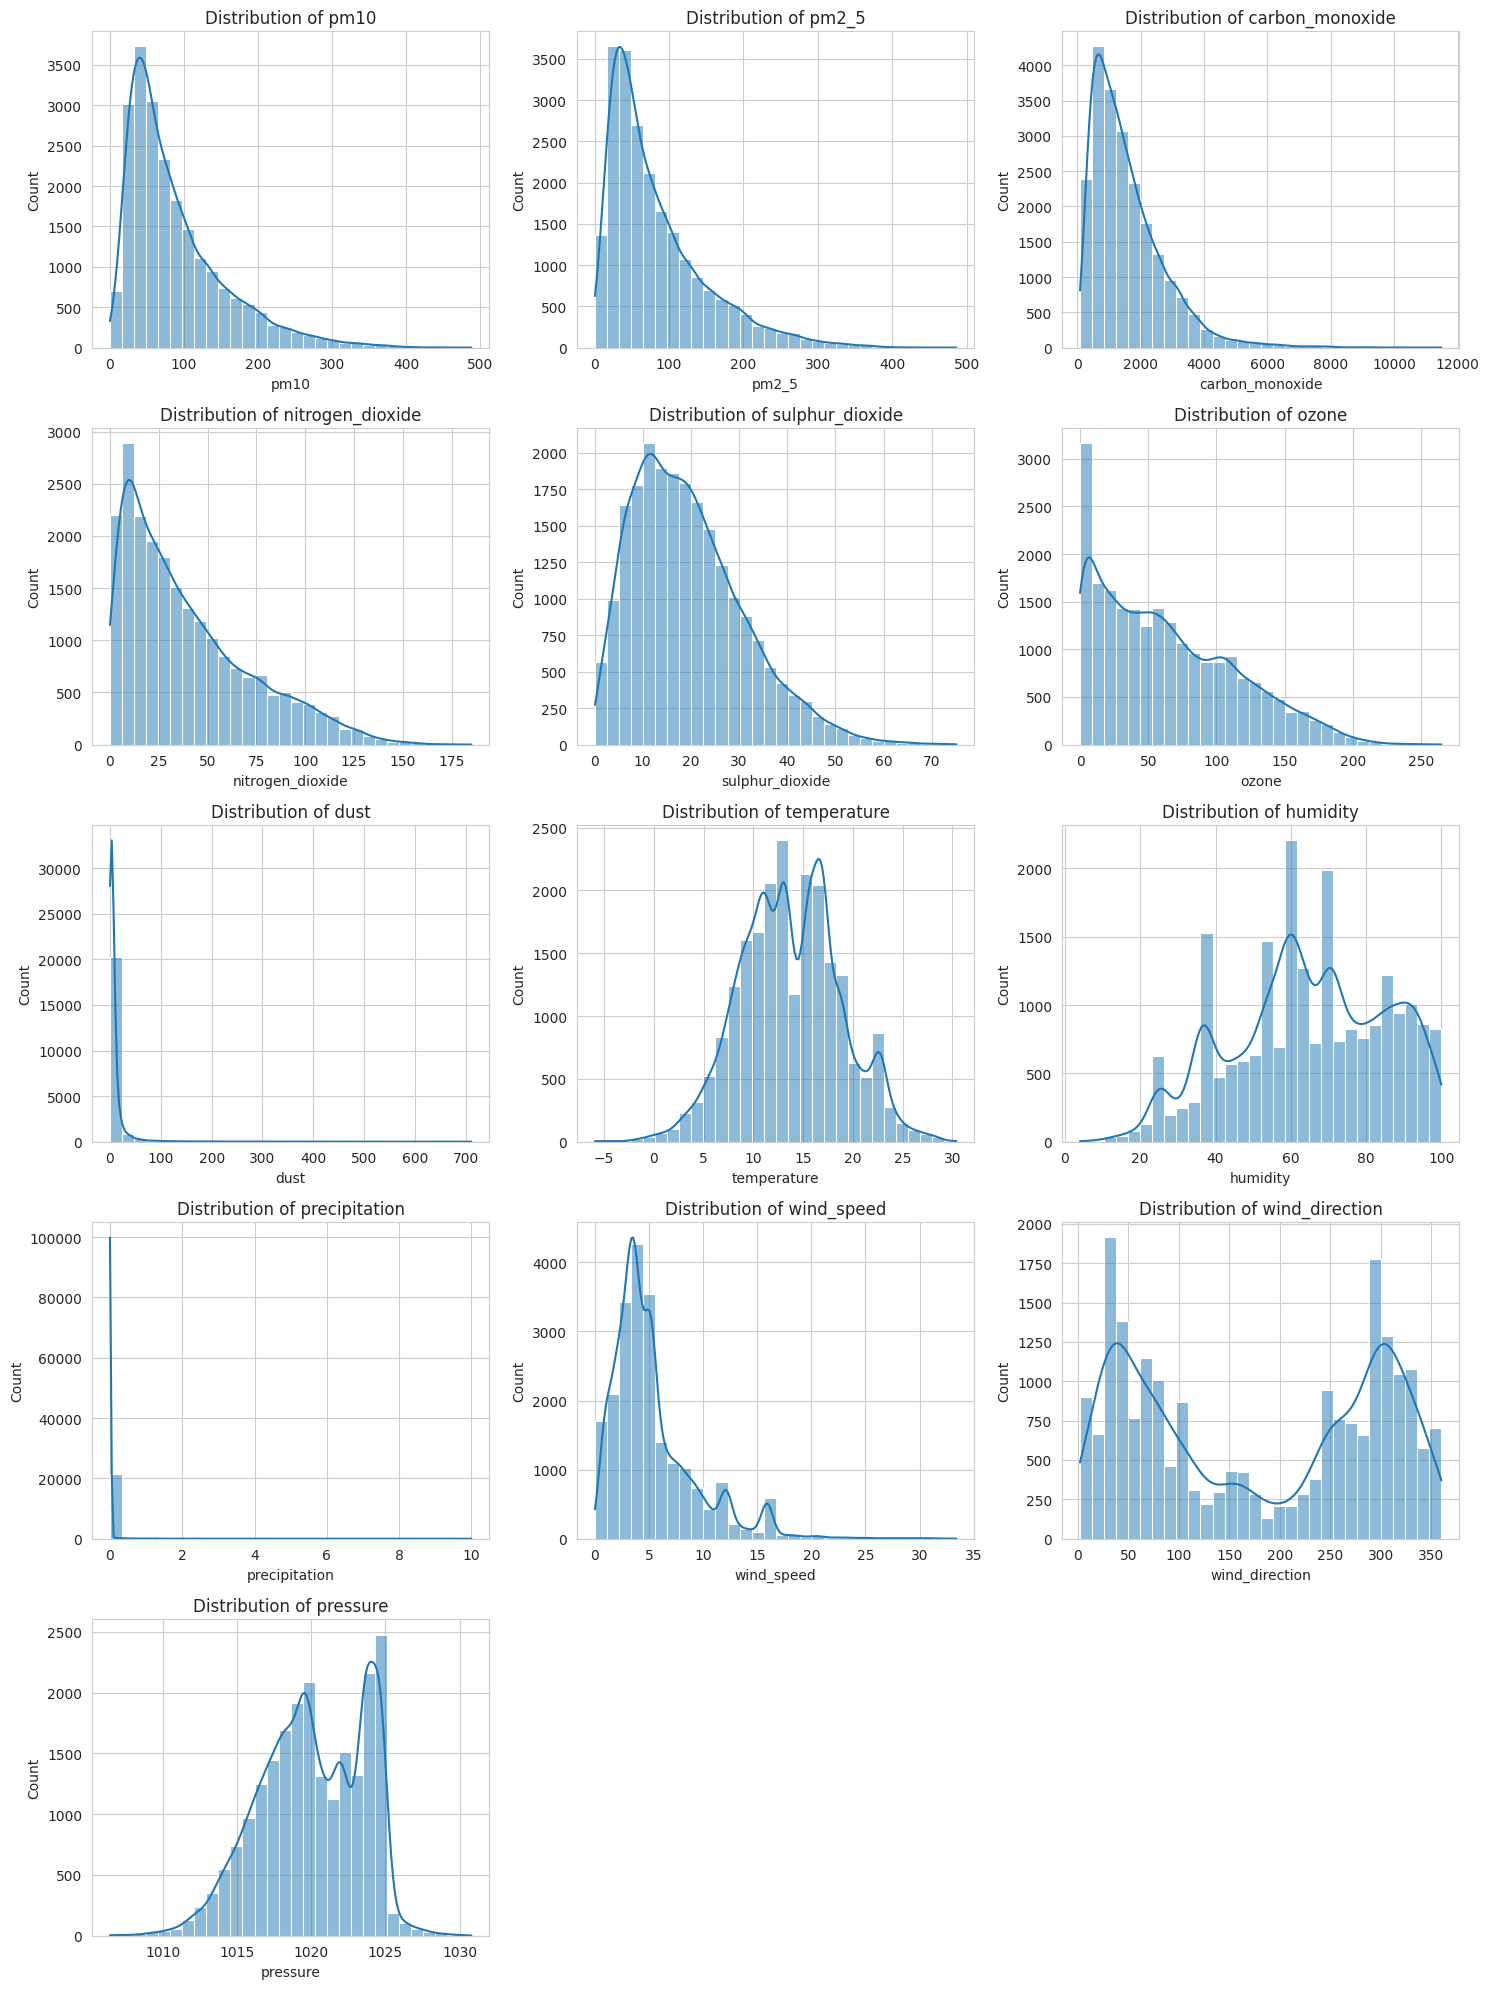

In [7]:

import matplotlib.pyplot as plt
import seaborn as sns

numeric_cols = ['pm10','pm2_5','carbon_monoxide','nitrogen_dioxide','sulphur_dioxide','ozone','dust',
                'temperature','humidity','precipitation','wind_speed','wind_direction','pressure']

# Determine grid size
n_cols = 3  # 3 plots per row
n_rows = (len(numeric_cols) + n_cols - 1) // n_cols  # number of rows

fig, axes = plt.subplots(n_rows, n_cols, figsize=(n_cols*5, n_rows*4))
axes = axes.flatten()  # flatten to easily iterate

for i, col in enumerate(numeric_cols):
    sns.histplot(df[col], bins=30, kde=True, ax=axes[i])
    axes[i].set_title(f'Distribution of {col}')
    
# Hide empty subplots if any
for j in range(i+1, len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()

**PM2.5 over time**

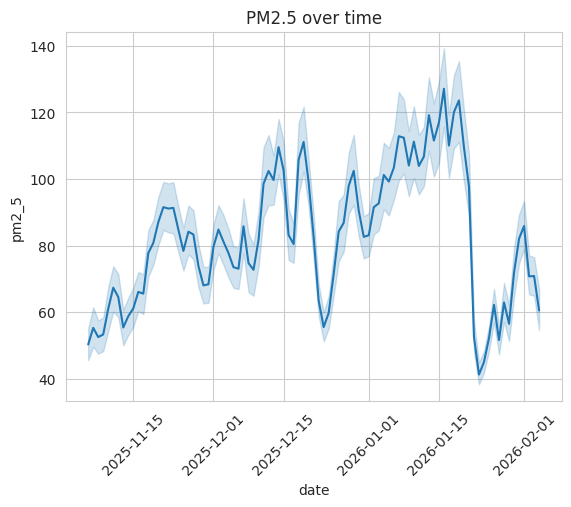

In [8]:

sns.lineplot(x='date', y='pm2_5', data=df)
plt.title('PM2.5 over time')
plt.xticks(rotation=45)  # rotate labels 45 degrees to improve visibility
plt.show()

From the plot:
  **PM2.5 is highest in mid of January → likely winter months,more pollution due to:**
* Lower temperature 
* less vertical mixing of air
* Increased use of heaters/firewoodFog trapping pollutants
* **Improvement in February → slightly warmer weather, wind, or reduced emissions.**



**Data Balanceness and Variance**

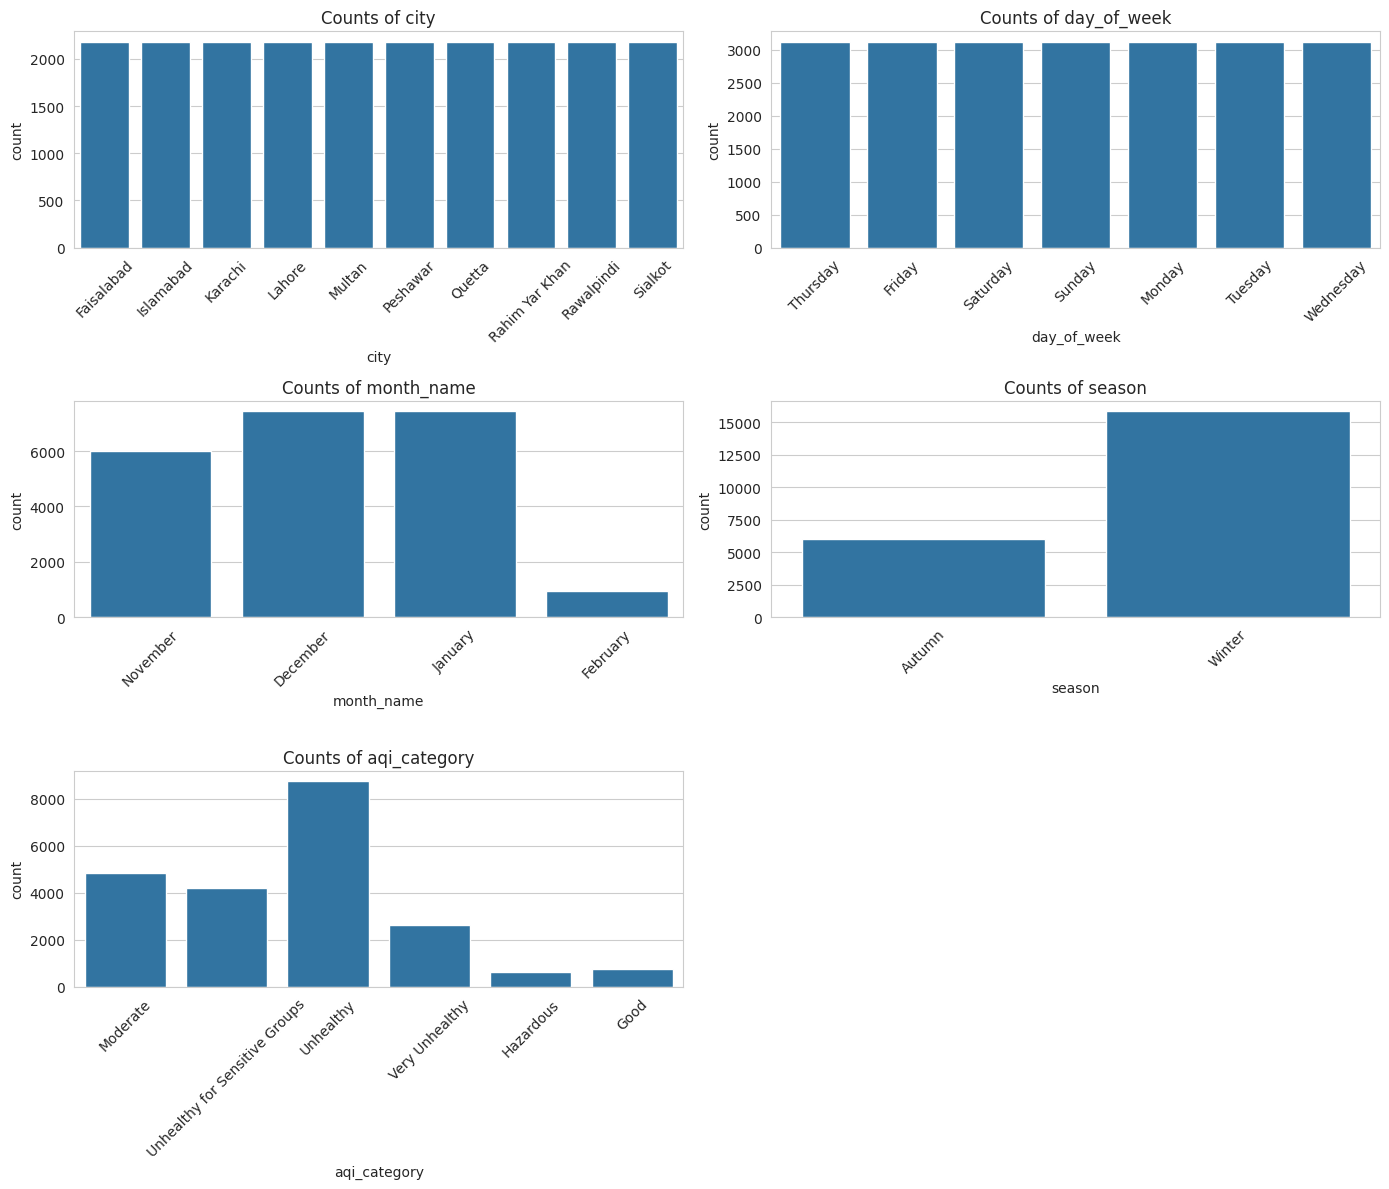

In [9]:
import matplotlib.pyplot as plt
import seaborn as sns

categorical_cols = ['city','day_of_week','month_name','season','aqi_category']

# Determine grid size
n_cols = 2  # 2 columns in the grid
n_rows = (len(categorical_cols) + 1) // n_cols  # number of rows

fig, axes = plt.subplots(n_rows, n_cols, figsize=(14, n_rows*4))
axes = axes.flatten()  # flatten to easily iterate

for i, col in enumerate(categorical_cols):
    sns.countplot(x=col, data=df, ax=axes[i])
    axes[i].set_title(f'Counts of {col}')
    axes[i].tick_params(axis='x', rotation=45)  # rotate x labels for readability

# Hide empty subplots if any
for j in range(i+1, len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()

It's worth to mention that this Dataset only contains data from November to February, mostly winter and autumn, so the model may not capture seasonal patterns for spring and summer.

### PM 2.5 by city/season

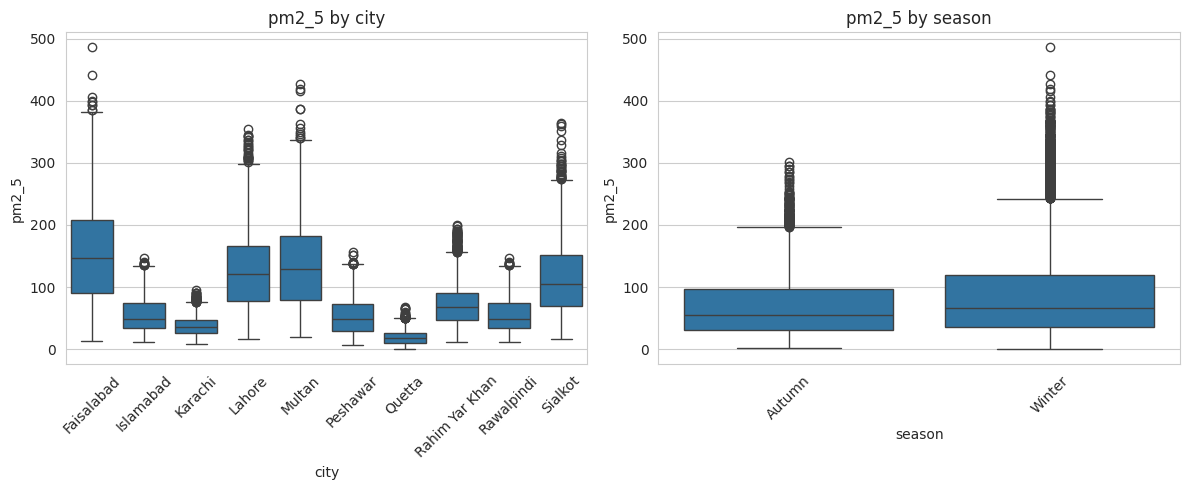

In [10]:

box_cols = ['city', 'season']
target_col = 'pm2_5'

# Set up grid
n_cols = 2  # two plots per row
n_rows = 1  # only one row needed
fig, axes = plt.subplots(n_rows, n_cols, figsize=(n_cols*6, n_rows*5))

axes = axes.flatten()

for i, col in enumerate(box_cols):
    sns.boxplot(x=col, y=target_col, data=df, ax=axes[i])
    axes[i].set_title(f'{target_col} by {col}')
    axes[i].tick_params(axis='x', rotation=45)  # rotate x labels for readability

plt.tight_layout()
plt.show()

**Observations from PM2.5 Analysis:**

Among the cities, Quetta has the cleanest air, with the lowest PM2.5 levels.

Faisalabad shows the highest PM2.5 values among all cities.

Seasonal effect is evident: winter has slightly higher PM2.5 concentrations than autumn, indicating more air pollution in colder months.

### PM2.5 on Weekends vs Weekdays

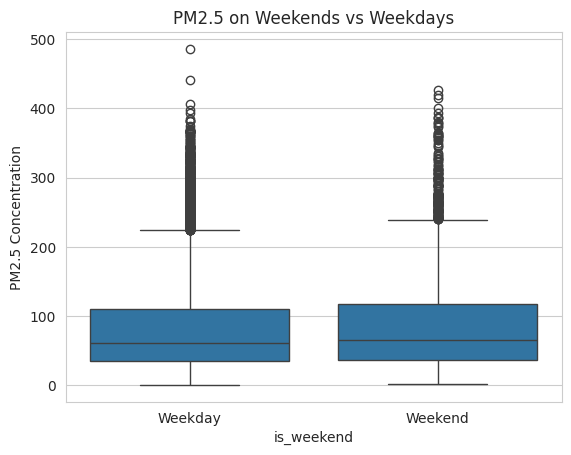

In [11]:

sns.boxplot(x='is_weekend', y='pm2_5', data=df)
plt.xticks([0,1], ['Weekday', 'Weekend'])  # replace 0/1 with labels
plt.title('PM2.5 on Weekends vs Weekdays')
plt.ylabel('PM2.5 Concentration')
plt.show()

In [12]:
df.groupby('is_weekend')['pm2_5'].mean().rename({0:'Weekday', 1:'Weekend'})

is_weekend
Weekday    82.452538
Weekend    84.257147
Name: pm2_5, dtype: float64

**Observation: PM2.5 on Weekends vs Weekdays**

The average PM2.5 on weekdays is approximately 82.45 µg/m³.

The average PM2.5 on weekends is slightly higher at 84.26 µg/m³.

Interpretation: Contrary to what we might expect, weekends in this dataset have a slightly higher PM2.5, which could be due to localized activities, festivals, or other sources of pollution rather than regular traffic/industrial patterns.

**Correlation and Relationships**

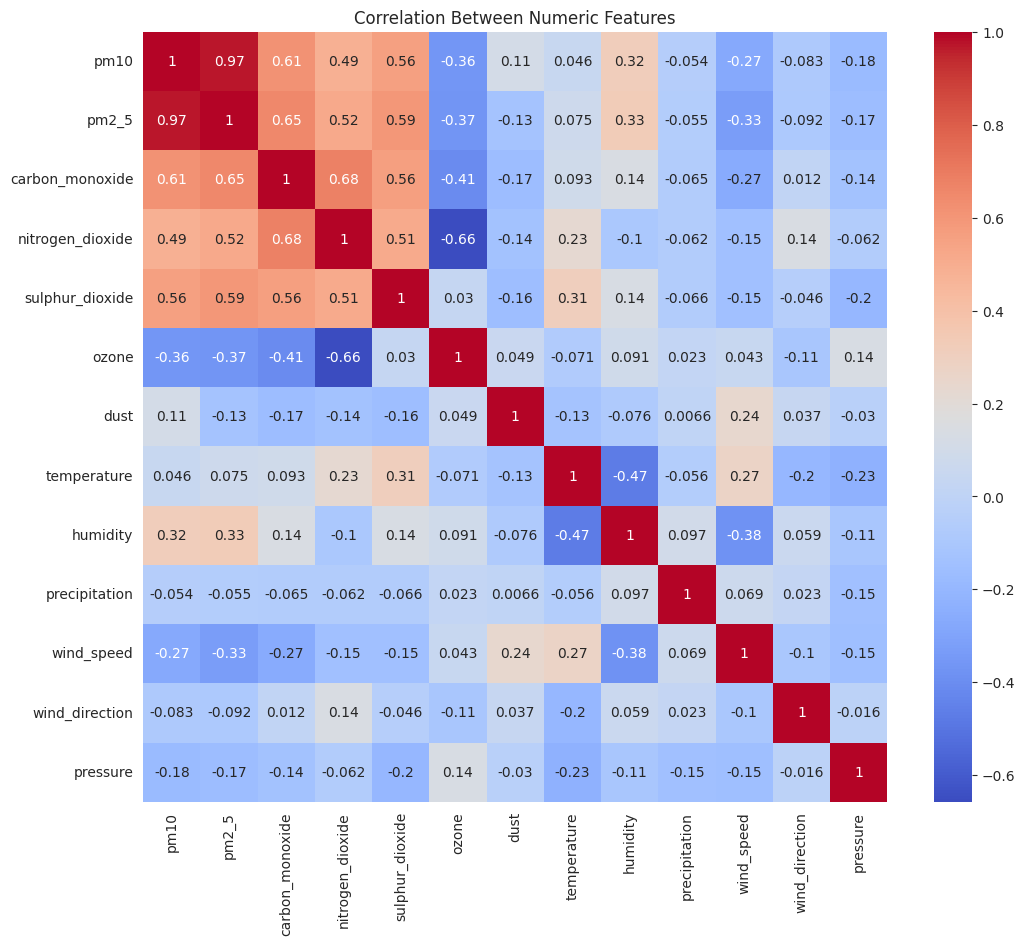

In [13]:
plt.figure(figsize=(12,10))
sns.heatmap(df[numeric_cols].corr(), annot=True, cmap='coolwarm')
plt.title('Correlation Between Numeric Features')
plt.show()

**Observations:**
 From the correlation heatmap, PM2.5 shows strong positive correlations ( > 0.5 ) with carbon monoxide, sulphur dioxide, nitrogen dioxide, and ozone. This indicates that these pollutants tend to increase together, likely because they share common sources such as traffic, industries, and combustion activities.

Also, **PM2.5 shows a moderate negative correlation** (-0.33) with wind speed, indicating that higher wind tends to reduce PM2.5. However, the correlation is not very strong, likely because other factors like temperature, humidity, and city-specific emissions also influence pollution levels.

## Data Preprocessing

**Step 1**: Load and Inspect Data

In [14]:

 #Check info, types, null values, and basic stats
df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 21840 entries, 0 to 21839
Data columns (total 26 columns):
 #   Column            Non-Null Count  Dtype         
---  ------            --------------  -----         
 0   timestamp         21840 non-null  datetime64[ns]
 1   city              21840 non-null  object        
 2   latitude          21840 non-null  float64       
 3   longitude         21840 non-null  float64       
 4   pm10              21840 non-null  float64       
 5   pm2_5             21840 non-null  float64       
 6   carbon_monoxide   21840 non-null  float64       
 7   nitrogen_dioxide  21840 non-null  float64       
 8   sulphur_dioxide   21840 non-null  float64       
 9   ozone             21840 non-null  float64       
 10  dust              21840 non-null  float64       
 11  temperature       21840 non-null  float64       
 12  humidity          21840 non-null  float64       
 13  precipitation     21840 non-null  float64       
 14  wind_speed        2184

**Step 2:** Handle Missing Values

In [15]:
# Check nulls
df.isnull().sum()

timestamp           0
city                0
latitude            0
longitude           0
pm10                0
pm2_5               0
carbon_monoxide     0
nitrogen_dioxide    0
sulphur_dioxide     0
ozone               0
dust                0
temperature         0
humidity            0
precipitation       0
wind_speed          0
wind_direction      0
pressure            0
date                0
hour                0
day_of_week         0
month               0
month_name          0
year                0
is_weekend          0
season              0
aqi_category        0
dtype: int64

**Observation:**
* There is no null value in any column of dataset.
* No need of dropping or imputation.


**Step 3:** Sort Data by City/time

In [16]:
# Sort by city first, then by date/time
df = df.sort_values(by=['city', 'date']).reset_index(drop=True)
df.head()

,timestamp,city,latitude,longitude,pm10,pm2_5,carbon_monoxide,nitrogen_dioxide,sulphur_dioxide,ozone,...,pressure,date,hour,day_of_week,month,month_name,year,is_weekend,season,aqi_category
0,2025-11-06 00:00:00,Faisalabad,31.4504,73.135,23.7,22.6,598.0,15.9,5.0,58.0,...,1023.4,2025-11-06,0,Thursday,11,November,2025,0,Autumn,Moderate
1,2025-11-06 01:00:00,Faisalabad,31.4504,73.135,25.4,24.2,790.0,21.7,5.6,51.0,...,1023.4,2025-11-06,1,Thursday,11,November,2025,0,Autumn,Moderate
2,2025-11-06 02:00:00,Faisalabad,31.4504,73.135,32.2,30.7,1048.0,29.4,6.5,42.0,...,1023.4,2025-11-06,2,Thursday,11,November,2025,0,Autumn,Moderate
3,2025-11-06 03:00:00,Faisalabad,31.4504,73.135,36.2,34.8,1176.0,33.2,7.2,42.0,...,1023.4,2025-11-06,3,Thursday,11,November,2025,0,Autumn,Moderate
4,2025-11-06 04:00:00,Faisalabad,31.4504,73.135,34.7,33.3,1053.0,29.3,7.6,58.0,...,1023.4,2025-11-06,4,Thursday,11,November,2025,0,Autumn,Moderate


**Step 4:** Encode Catagorical Columns

In [17]:
from sklearn.preprocessing import LabelEncoder

categorical_cols = ['city', 'day_of_week', 'season', 'aqi_category']
label_encoders = {}  # dictionary to store encoders for future use

for col in categorical_cols:
    le = LabelEncoder()
    df[col] = le.fit_transform(df[col])
    label_encoders[col] = le  # save encoder

**Step 5:** Drop Irrevalant/Duplicate Featues

In [18]:
df.drop(['latitude','longitude','timestamp','date','month_name'], axis=1, inplace=True, errors='ignore')

**Reasons:** 

* timestamp : removed because we already extracted hour, day_of_week, month,year
* date :  removed as it’s redundant after extracting features
* month_name : removed because we have numeric month already
* latitude,longitude -> removed since we already have encoded city name



In [19]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 21840 entries, 0 to 21839
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   city              21840 non-null  int64  
 1   pm10              21840 non-null  float64
 2   pm2_5             21840 non-null  float64
 3   carbon_monoxide   21840 non-null  float64
 4   nitrogen_dioxide  21840 non-null  float64
 5   sulphur_dioxide   21840 non-null  float64
 6   ozone             21840 non-null  float64
 7   dust              21840 non-null  float64
 8   temperature       21840 non-null  float64
 9   humidity          21840 non-null  float64
 10  precipitation     21840 non-null  float64
 11  wind_speed        21840 non-null  float64
 12  wind_direction    21840 non-null  float64
 13  pressure          21840 non-null  float64
 14  hour              21840 non-null  int64  
 15  day_of_week       21840 non-null  int64  
 16  month             21840 non-null  int64 

**Final Thoughts:** After completing preprocessing, the dataset consists of 21 features and 21,840 records, with no missing values across any column. Categorical attributes including city, day_of_week, season, and aqi_category have been encoded into numerical representations. Since all variables are now in numeric format, the dataset is well-structured and ready for feature analysis, visualization, and predictive modeling.

## Saving the Processed Dataset

**Step 1: Save the processed dataset**

In [23]:
df.to_csv("processed_air_quality_data.csv", index=False)

**Step 2: Save the label encoders**

In [21]:
import pickle

with open("label_encoders.pkl", "wb") as f:
    pickle.dump(label_encoders, f)